In [1]:
from scipy.stats import randint, uniform
import sys
from pathlib import Path

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from src.utils.tune_hyperparameters import ModelTuner, PipelineTuner
from src.utils.load_data import get_split_from_file
filename = r"../../data/processed/no_cat_unknown.csv"


# model
from sklearn.ensemble import RandomForestClassifier


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_state = 0


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 1/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.956, test=0.618) total time=   0.6s
[CV 2/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 2/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.962, test=0.615) total time=   0.6s
[CV 3/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 3/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.954, test=0.597) total time=   0.6s
[CV 4/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 4/5; 1/100] END classifier__bootstrap=True, classifi

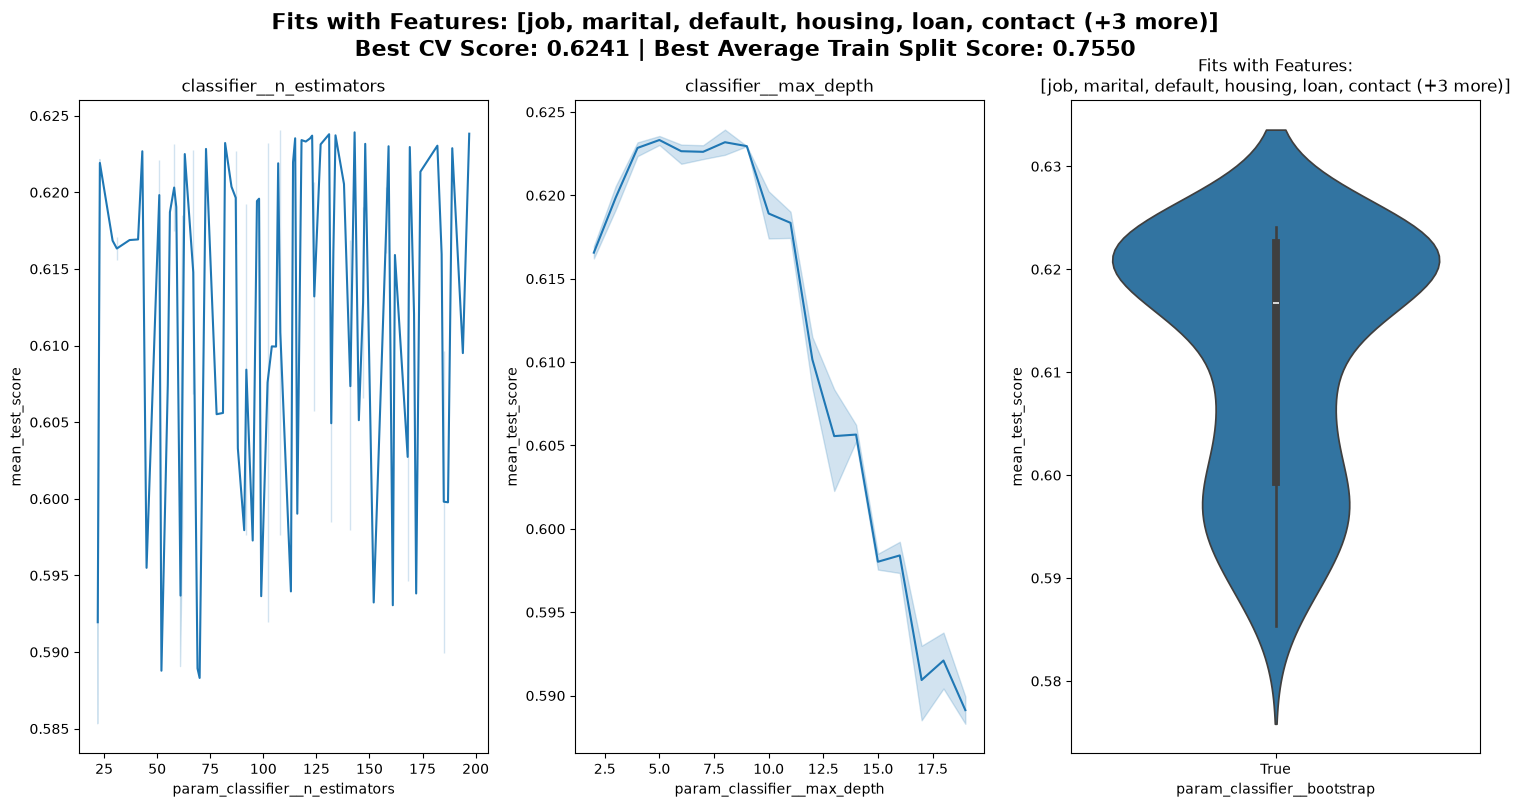



Feature Permutation Importance
______________________
balance: 0.035 +/- 0.006
housing: 0.024 +/- 0.004
marital: 0.020 +/- 0.007
age: 0.015 +/- 0.003
loan: 0.008 +/- 0.004
job: 0.007 +/- 0.004
education: 0.003 +/- 0.002
contact: 0.002 +/- 0.002
default: -0.002 +/- 0.001

______________________



classifier:  RandomForestClassifier(max_depth=8, n_estimators=108, random_state=0) 





e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:395: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


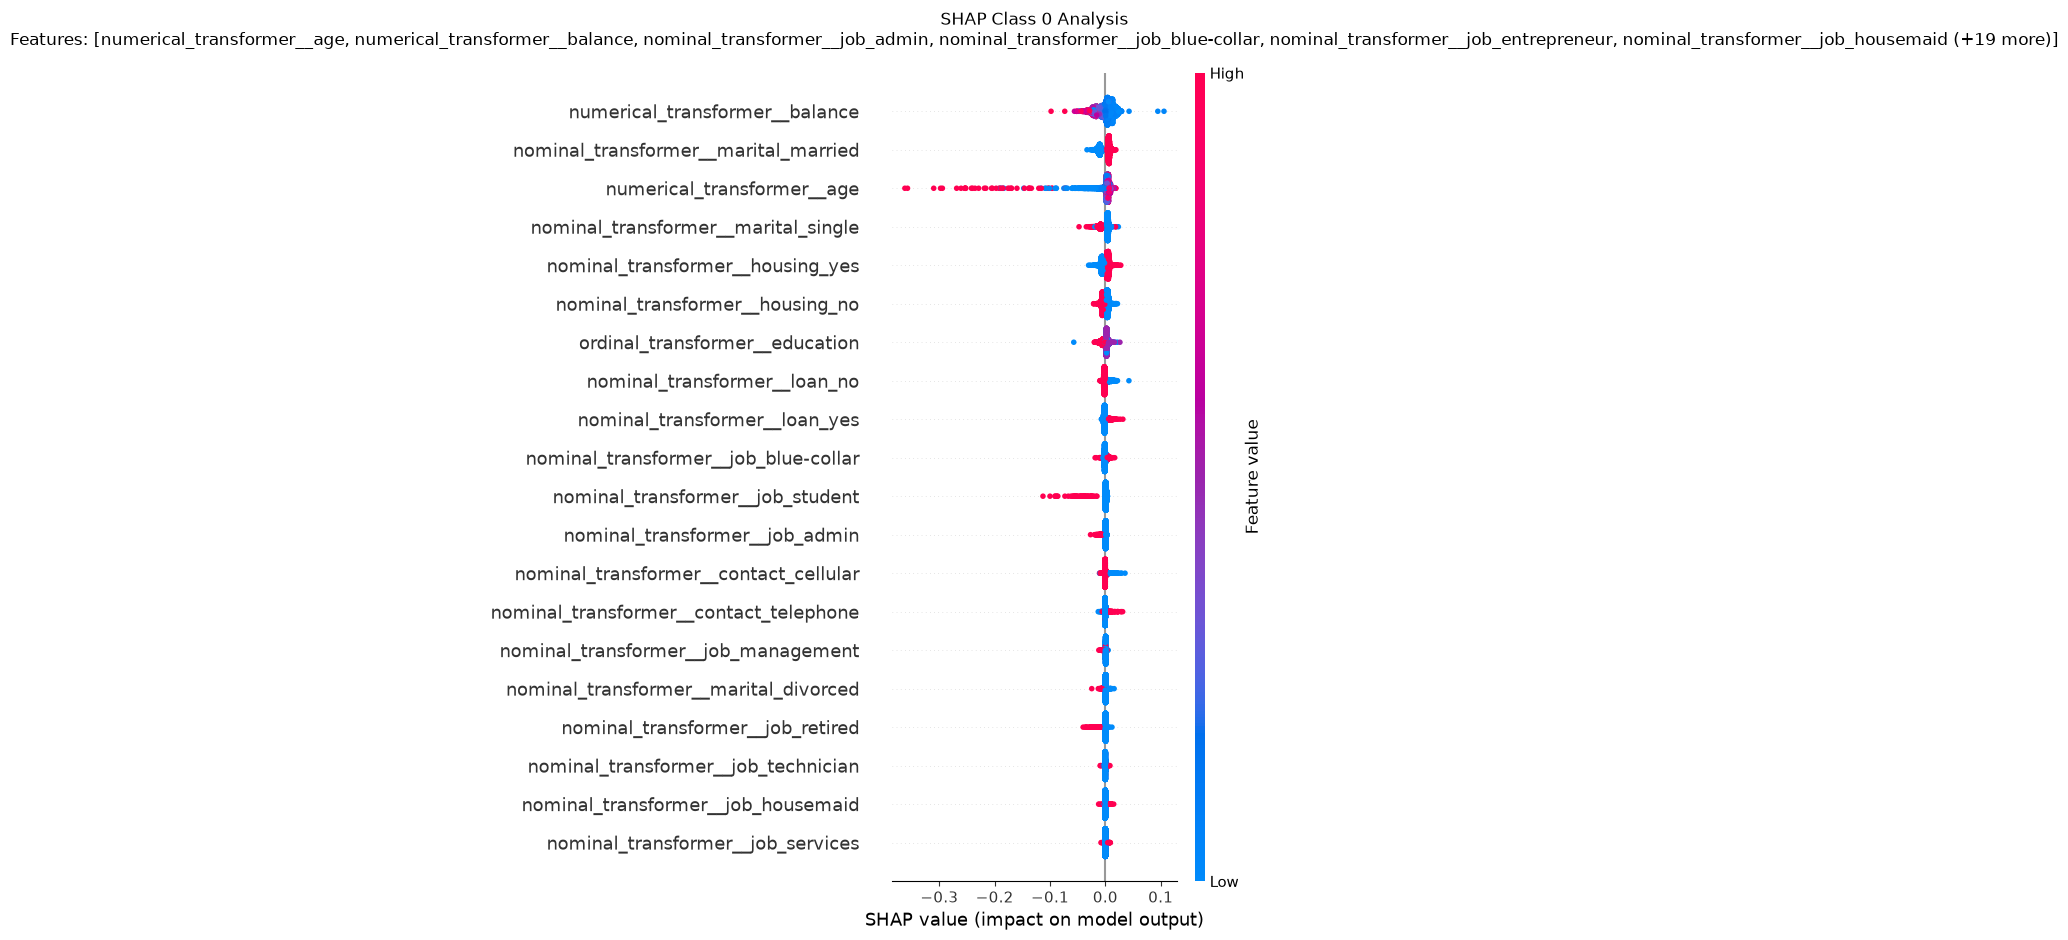

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:395: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


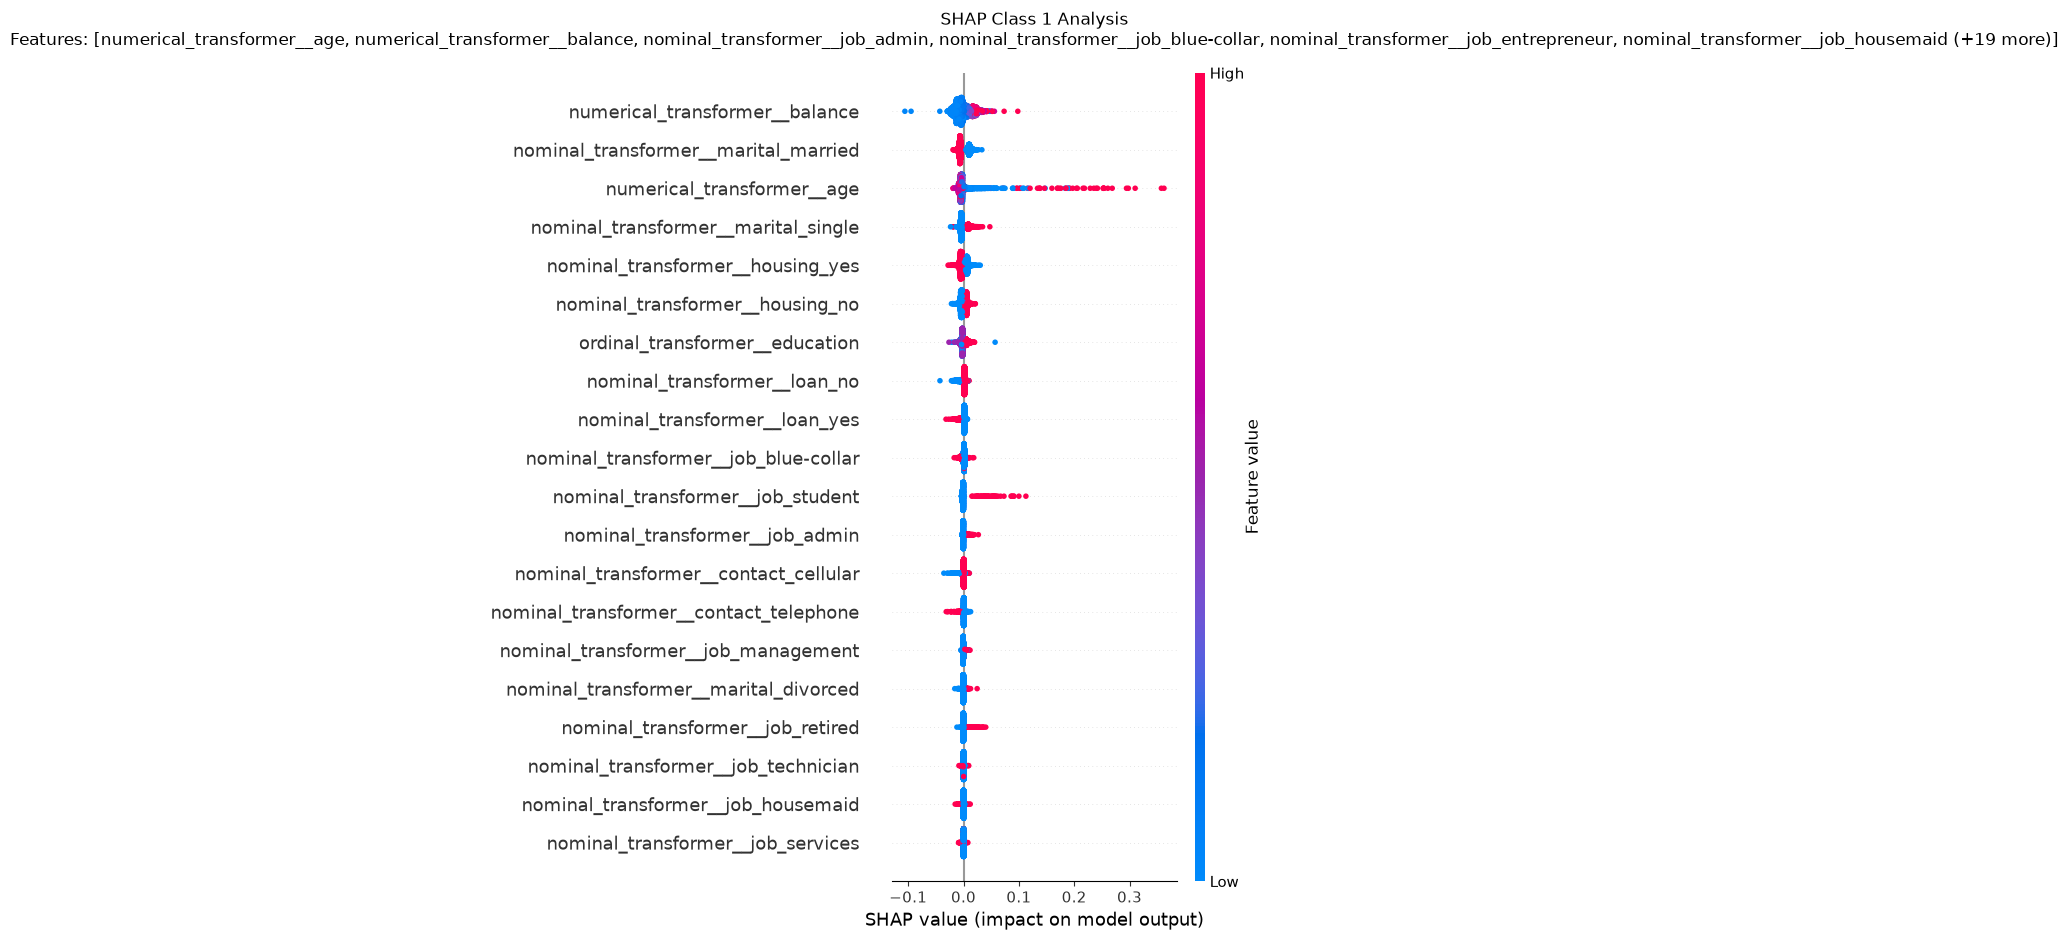

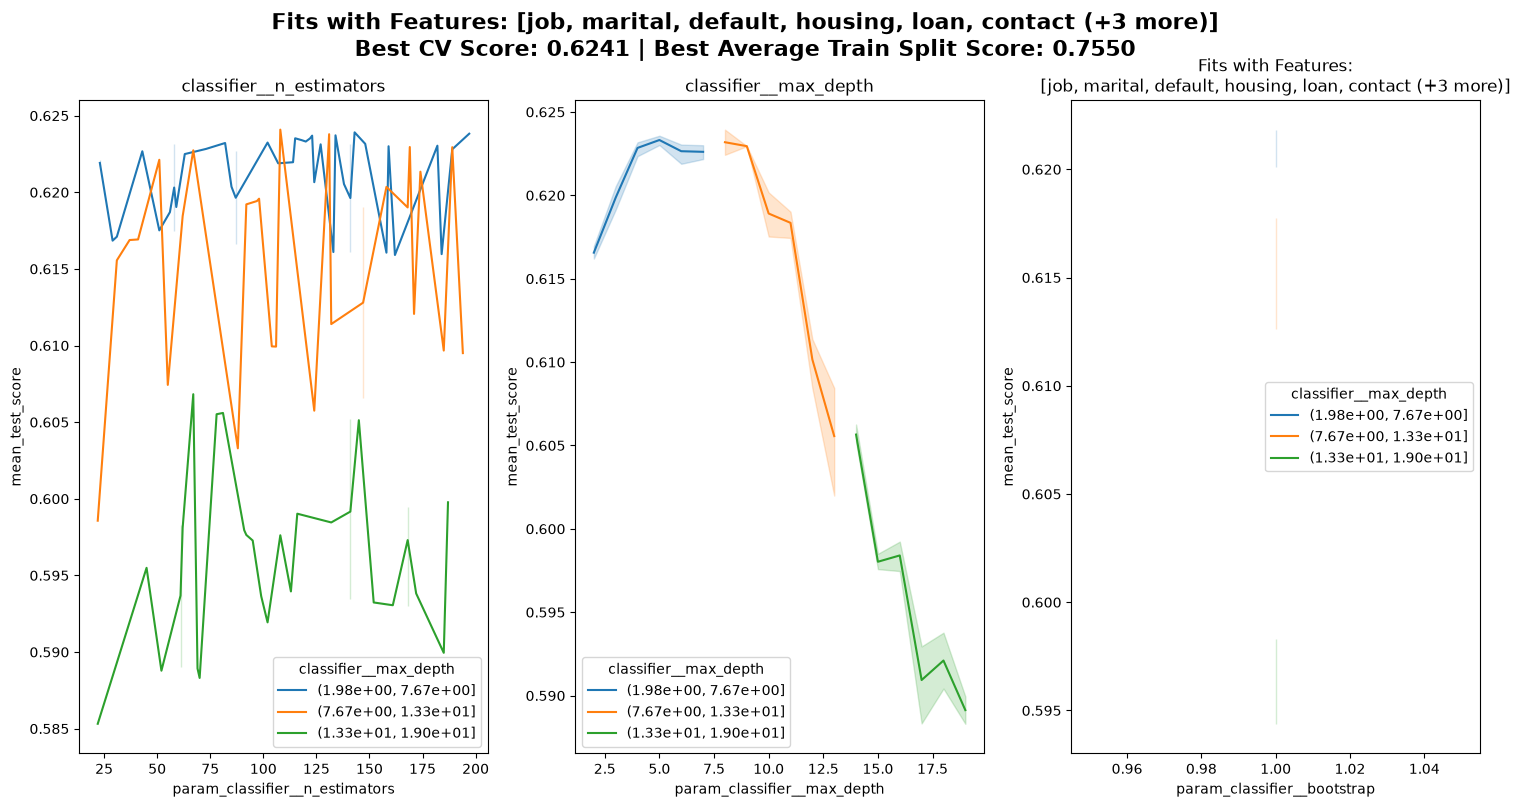

In [3]:
# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact',]

ordinal_features = ['education',]
education_order = ["primary", "secondary", "tertiary"]

numerical_features = ['age', 'balance',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=random_state)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": randint(20, 200),
    "classifier__max_depth": randint(2,20),
    # "classifier__min_samples_split": randint(2, 21),
    # "classifier__min_samples_leaf": randint(1, 21),
    # "classifier__max_features": ["sqrt", "log2", None],
    # "classifier__min_weight_fraction_leaf": uniform(0.0, 0.5),
    "classifier__bootstrap": [True],
}


split = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t = PipelineTuner(pipeline, split=split, featureNames=all_features, random_state = random_state)
search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100, scoring = 'roc_auc')
t.feature_permutation(search.best_params_, scoring = 'roc_auc')
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="classifier__max_depth")

In [4]:
t.predict_test_split(t.last_search.best_params_, scoring = ["roc_auc","accuracy"])

{'roc_auc': 0.6232871345271528, 'accuracy': 0.9117702985358433}